# scorecardpipeline 自动模型报告

本 notebook 演示如何使用 `scorecardpipeline` 快速构建评分卡模型，并使用 `auto_model_report` 自动生成模型评估报告。

## 功能特点

- 端到端评分卡建模（Pipeline 风格）
- 自动生成多 Sheet 结构 Excel 报告
- 包含 KS/AUC/PSI 等核心指标
- 逐特征分箱分析与可视化
- 评分卡参数与刻度配置

### 导入依赖

In [1]:
import sys
sys.path.append("../")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scorecardpipeline as sp

print(f"scorecardpipeline 版本: {sp.__version__}")

scorecardpipeline 版本: 0.1.38.09


### 加载数据

使用 scorecardpipeline 内置的 German Credit 数据集

In [3]:
# 加载数据
# 注意：原始标签列为 'creditability'，需要映射为 0/1
target = 'creditability'
data = sp.germancredit()
data[target] = data[target].map({'good': 0, 'bad': 1})

print(f"数据集大小: {data.shape}")
print(f"目标分布:\n{data[target].value_counts()}")

数据集大小: (1000, 21)
目标分布:
creditability
0    700
1    300
Name: count, dtype: int64


In [4]:
# 划分训练集和测试集
train, test = train_test_split(data, test_size=0.3, random_state=42)
print(f"训练集样本数: {len(train)}, 测试集样本数: {len(test)}")
print(f"训练集坏样本率: {train[target].mean():.2%}")
print(f"测试集坏样本率: {test[target].mean():.2%}")

训练集样本数: 700, 测试集样本数: 300
训练集坏样本率: 29.86%
测试集坏样本率: 30.33%


### 构建 Pipeline

使用 scorecardpipeline 的 Pipeline 构建端到端评分卡建模流程

In [5]:
# 构建 Pipeline
feature_pipeline = sp.Pipeline([
    ('preprocessing_select', sp.FeatureSelection(target=target, engine='scorecardpy')),
    ('combiner', sp.Combiner(target=target, min_bin_size=0.2)),
    ('transform', sp.WOETransformer(target=target)),
    ('processing_select', sp.FeatureSelection(target=target, engine='toad')),
    ('stepwise', sp.StepwiseSelection(target=target)),
])

In [6]:
# 训练 Pipeline
# 注意：需要传入完整数据（含目标列），Pipeline 会自动处理目标列
feature_pipeline.fit(train)

[INFO] filtering variables ...


Pipeline(steps=[('preprocessing_select',
                 FeatureSelection(target='creditability')),
                ('combiner',
                 Combiner(min_bin_size=0.2, target='creditability')),
                ('transform',
                 WOETransformer(exclude=[], target='creditability')),
                ('processing_select',
                 FeatureSelection(engine='toad', target='creditability')),
                ('stepwise', StepwiseSelection(target='creditability'))])

In [7]:
# WOE 转换
woe_train = feature_pipeline.transform(train)
woe_test = feature_pipeline.transform(test)

print(f"WOE转换后特征数: {woe_train.shape[1]}")
woe_train.head()

WOE转换后特征数: 9


,housing,property,age_in_years,purpose,savings_account_and_bonds,status_of_existing_checking_account,credit_history,credit_amount,creditability
541,0.486385,0.181766,-0.394563,0.483736,0.224717,-0.978472,0.287256,-0.461915,0
440,-0.218116,0.181766,-0.394563,0.483736,0.224717,-0.978472,0.287256,-0.461915,0
482,0.486385,0.181766,-0.394563,-0.390943,-0.629823,0.788869,0.287256,-0.461915,0
422,-0.218116,-0.544924,-0.394563,0.483736,0.224717,0.389053,-0.867540,0.127061,0
778,-0.218116,0.181766,-0.394563,-0.390943,-0.629823,-0.978472,-0.867540,0.548079,0


### 构建逻辑回归模型

In [8]:
# 构建逻辑回归模型
logistic = sp.ITLubberLogisticRegression(target=target)
logistic.fit(woe_train)

# 查看入模特征
print(f"入模特征: {list(logistic.feature_names_in_)}")

入模特征: ['housing', 'property', 'age_in_years', 'purpose', 'savings_account_and_bonds', 'status_of_existing_checking_account', 'credit_history', 'credit_amount']


In [9]:
# 查看模型摘要
logistic.summary()

,Coef.,Std.Err,z,P>|z|,[ 0.025,0.975 ],VIF
const,-0.853023,0.095860,-8.898648,5.653082e-19,-1.040908,-0.665138,1.050301
housing,0.686183,0.288859,2.375497,1.752533e-02,0.120020,1.252347,1.043465
property,0.706635,0.308270,2.292261,2.189058e-02,0.102426,1.310843,1.034041
age_in_years,0.822212,0.294219,2.794554,5.197138e-03,0.245542,1.398882,1.071333
purpose,0.906010,0.218257,4.151121,3.308515e-05,0.478227,1.333794,1.038664
savings_account_and_bonds,0.681405,0.263870,2.582355,9.812857e-03,0.164221,1.198590,1.059537
status_of_existing_checking_account,0.806588,0.128079,6.297599,3.022905e-10,0.555554,1.057623,1.107430
credit_history,0.745732,0.202456,3.683434,2.301132e-04,0.348919,1.142545,1.078023
credit_amount,0.866222,0.219050,3.954454,7.670949e-05,0.436885,1.295559,1.041104


### 构建评分卡

In [10]:
# 构建评分卡
# 使用 pipeline 和 pretrain_lr 参数
scorecard = sp.ScoreCard(target=target, pipeline=feature_pipeline, pretrain_lr=logistic)
# 在 WOE 转换后的数据上训练评分卡
scorecard.fit(woe_train)

ScoreCard(combiner=<toad.transform.Combiner object at 0x7fb9415b0cd0>,
          pipeline=Pipeline(steps=[('preprocessing_select',
                                    FeatureSelection(target='creditability')),
                                   ('combiner',
                                    Combiner(min_bin_size=0.2,
                                             target='creditability')),
                                   ('transform',
                                    WOETransformer(exclude=[],
                                                   target='creditability')),
                                   ('processing_select',
                                    FeatureSelection(engine='toad',
                                                     target='creditability')),
                                   ('stepwise',
                                    StepwiseSelection(target='creditability'))]),
          pretrain_lr=ITLubberLogisticRegression(target='creditability'),
          target='creditability',
          transer=<toad.transform.WOETransformer object at 0x7fb9415b0d90>)

In [11]:
# 查看评分卡刻度配置
scorecard.scorecard_scale()

,刻度项,刻度值,备注
0,base_odds,35.000000,根据业务经验设置的基础比率（违约概率/正常概率），估算方法：（1-样本坏客户占比）/坏客户占比
1,base_score,750.000000,基础ODDS对应的分数
2,rate,2.000000,设置分数的倍率
3,pdo,60.000000,表示分数增长PDO时，ODDS值增长到RATE倍
4,B,86.561702,补偿值，计算方式：pdo / ln(rate)
5,A,442.243019,刻度，计算方式：base_score - B * ln(base_odds)


In [12]:
# 定义特征含义映射（用于报告展示）
feature_map = {
    'status_of_existing_checking_account': '支票账户状态',
    'credit_history': '信用历史',
    'purpose': '贷款目的',
    'credit_amount': '贷款金额',
    'savings_account_and_bonds': '储蓄账户',
    'present_employment_since': '就业时长',
    'housing': '住房情况',
    'property': '财产情况',
    'age_in_years': '年龄',
}

# 查看评分卡分值表
scorecard.scorecard_points(feature_map=feature_map)

,变量名称,变量含义,变量分箱,对应分数
0,housing,住房情况,own,77.4657
1,housing,住房情况,"rent,for free",35.6204
2,property,财产情况,real estate,97.8419
3,property,财产情况,"car or other, not in attribute Savings account...",53.3921
4,age_in_years,年龄,"[负无穷 , 35)",44.6394
5,age_in_years,年龄,"[35 , 正无穷)",92.5921
6,purpose,贷款目的,"radio/television,car (used),furniture/equipmen...",95.1703
7,purpose,贷款目的,"domestic appliances,education,car (new),busine...",26.5729
8,savings_account_and_bonds,储蓄账户,"unknown/ no savings account,500 <= ... < 1000 ...",101.6595
9,savings_account_and_bonds,储蓄账户,"... < 100 DM,100 <= ... < 500 DM",51.2556


### 模型预测与评估

In [13]:
# 在测试集上预测评分
test_score = scorecard.predict(test)
print(f"测试集评分范围: [{test_score.min():.2f}, {test_score.max():.2f}]")
print(f"测试集评分均值: {test_score.mean():.2f}")

测试集评分范围: [290.29, 772.76]
测试集评分均值: 539.04


In [14]:
# 计算 KS 和 AUC
y_test = test[target]
test_proba = scorecard.predict_proba(test)[:, 1]

test_ks = sp.KS(test_proba, y_test)
test_auc = sp.AUC(test_proba, y_test)

print(f"测试集 KS: {test_ks:.4f}")
print(f"测试集 AUC: {test_auc:.4f}")

测试集 KS: 0.4721
测试集 AUC: 0.7631


### 自动生成模型报告

使用 `auto_model_report` 一键生成多 Sheet 结构的 Excel 模型评估报告

模型评估快速报告

【模型性能指标】
 统计项    训练集      测试集
  KS 0.4755   0.4721
 AUC 0.7980   0.7631
 样本数    700 300.0000
坏样本率 0.2986   0.3033
 PSI      \   0.3878

【训练集评分分箱效果】
                   分箱  样本总数  好样本数  坏样本数   样本占比  好样本占比  坏样本占比   坏样本率  LIFT值  累积LIFT值    坏账改善  累积坏账改善  分档KS值
     [负无穷 , 393.9398)    67    18    49 0.0957 0.0367 0.2344 0.7313 2.4495   2.4495  0.1534  0.1534 0.1978
[393.9398 , 435.7852)    72    30    42 0.1029 0.0611 0.2010 0.5833 1.9537   2.1927  0.1093  0.2955 0.3376
[435.7852 , 476.7548)    69    32    37 0.0986 0.0652 0.1770 0.5362 1.7960   2.0611  0.0870  0.4486 0.4495
[476.7548 , 506.9319)    72    48    24 0.1029 0.0978 0.1148 0.3333 1.1164   1.8182  0.0133  0.5455 0.4666
[506.9319 , 535.0556)    69    55    14 0.0986 0.1120 0.0670 0.2029 0.6796   1.5931 -0.0350  0.5897 0.4215
[535.0556 , 568.6969)    71    53    18 0.1014 0.1079 0.0861 0.2535 0.8491   1.4673 -0.0170  0.7010 0.3997
  [568.6969 , 600.15)    69    61     8 0.0986 0.1242 0.0383 0.1159 0.3883   1.3151 -0.0669  

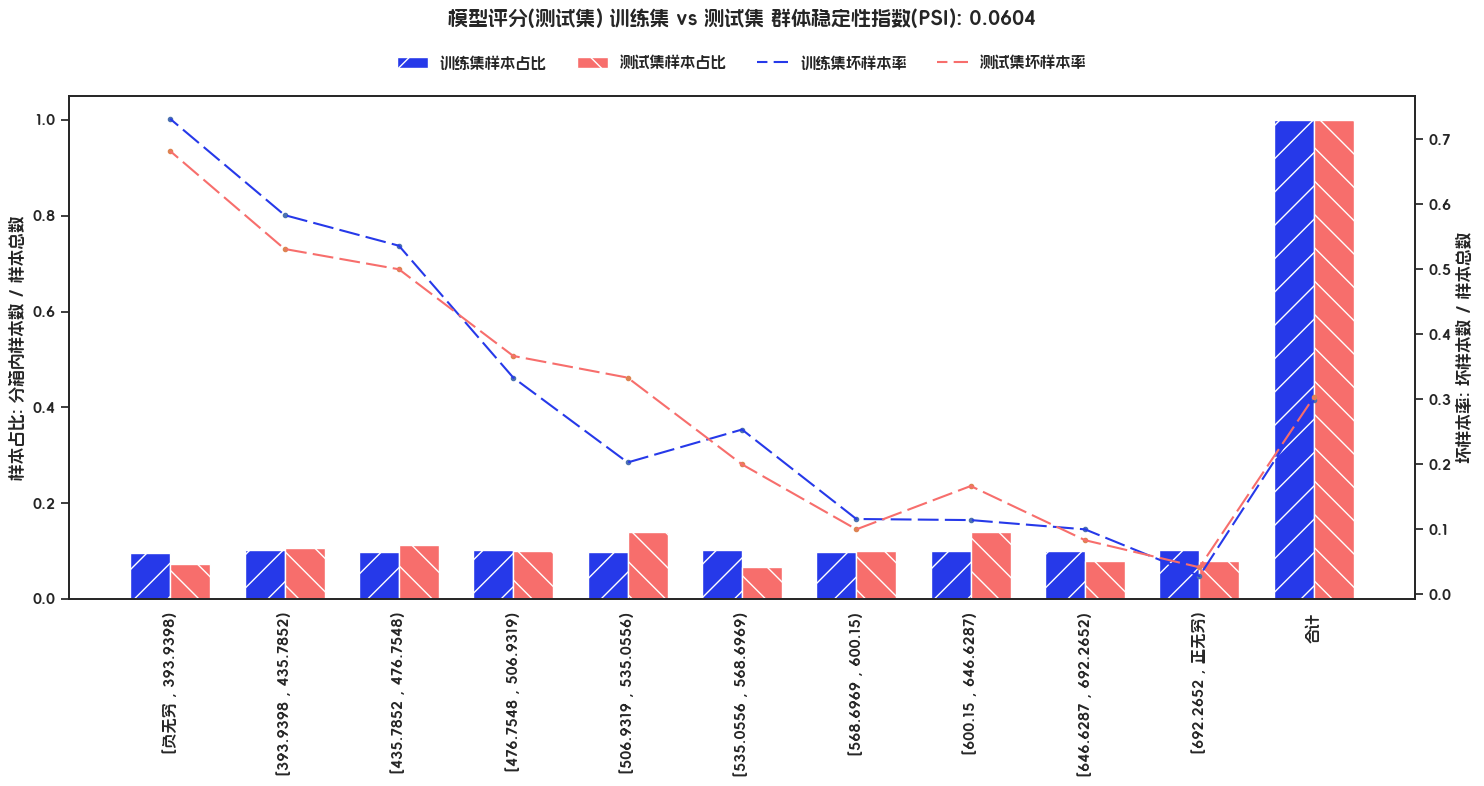

In [15]:
# 生成模型报告
# 需要传入包含目标列的数据集
report = sp.auto_model_report(
    model=scorecard,
    datasets={'train': train.copy(), 'test': test.copy()},
    target=target,
    excel_path='model_report.xlsx',
    n_bins=10,
    bin_method='quantile',
    with_plots=True,
    model_name='CreditScoreCard',
    project_desc='德国信贷评分卡模型',
    feature_map=feature_map,
    data_source='German Credit Dataset',
    verbose=True
)

In [16]:
# 查看报告文件
import os
if os.path.exists('model_report.xlsx'):
    print("\n报告文件已生成: model_report.xlsx")
    print(f"文件大小: {os.path.getsize('model_report.xlsx') / 1024:.2f} KB")
    
    # 查看生成的图表目录
    assets_dir = 'model_report_assets'
    if os.path.exists(assets_dir):
        print(f"\n图表目录: {assets_dir}")
        for f in os.listdir(assets_dir):
            print(f"  - {f}")


报告文件已生成: model_report.xlsx
文件大小: 8026.80 KB

图表目录: model_report_assets
  - bin_installment_rate_in_percentage_of_disposable_income_test.png
  - bin_present_residence_since_train.png
  - bin_telephone_train.png
  - bin_age_in_years_train.png
  - bin_test.png
  - bin_duration_in_month_train.png
  - bin_housing_test.png
  - score_psi_test.png
  - bin_credit_history_train.png
  - bin_status_of_existing_checking_account_test.png
  - bin_present_employment_since_test.png
  - bin_creditability_train.png
  - bin_number_of_people_being_liable_to_provide_maintenance_for_train.png
  - bin_present_residence_since_test.png
  - bin_duration_in_month_test.png
  - bin_other_installment_plans_test.png
  - bin_present_employment_since_train.png
  - ks_train.png
  - bin_housing_train.png
  - bin_credit_amount_test.png
  - bin_job_test.png
  - bin_telephone_test.png
  - bin_job_train.png
  - bin_creditability_test.png
  - bin_other_installment_plans_train.png
  - bin_personal_status_and_sex_train.png
  -

### 使用 QuickModelReport 类

直接使用 `QuickModelReport` 类进行更精细的控制

In [17]:
# 直接使用 QuickModelReport
report = sp.QuickModelReport(
    model=scorecard,
    datasets={'train': train.copy(), 'test': test.copy()},
    target=target,
)

# 打印报告摘要
report.print_report(n_bins=10)

模型评估快速报告

【模型性能指标】
 统计项    训练集      测试集
  KS 0.4755   0.4721
 AUC 0.7980   0.7631
 样本数    700 300.0000
坏样本率 0.2986   0.3033
 PSI      \   0.3878

【训练集评分分箱效果】
                   分箱  样本总数  好样本数  坏样本数   样本占比  好样本占比  坏样本占比   坏样本率  LIFT值  累积LIFT值    坏账改善  累积坏账改善  分档KS值
     [负无穷 , 393.9398)    67    18    49 0.0957 0.0367 0.2344 0.7313 2.4495   2.4495  0.1534  0.1534 0.1978
[393.9398 , 435.7852)    72    30    42 0.1029 0.0611 0.2010 0.5833 1.9537   2.1927  0.1093  0.2955 0.3376
[435.7852 , 476.7548)    69    32    37 0.0986 0.0652 0.1770 0.5362 1.7960   2.0611  0.0870  0.4486 0.4495
[476.7548 , 506.9319)    72    48    24 0.1029 0.0978 0.1148 0.3333 1.1164   1.8182  0.0133  0.5455 0.4666
[506.9319 , 535.0556)    69    55    14 0.0986 0.1120 0.0670 0.2029 0.6796   1.5931 -0.0350  0.5897 0.4215
[535.0556 , 568.6969)    71    53    18 0.1014 0.1079 0.0861 0.2535 0.8491   1.4673 -0.0170  0.7010 0.3997
  [568.6969 , 600.15)    69    61     8 0.0986 0.1242 0.0383 0.1159 0.3883   1.3151 -0.0669  

In [18]:
# 获取模型性能指标
report.get_metrics()

,统计项,训练集,测试集
0,KS,0.4755,0.4721
1,AUC,0.7980,0.7631
2,样本数,700,300.0000
3,坏样本率,0.2986,0.3033
4,PSI,\,0.3878


In [19]:
# 获取特征重要性
report.get_feature_importance(top_n=10)

,特征重要性,IV,KS,PSI


In [20]:
# 获取评分分箱效果
train_bin_table = report.get_bin_table(dataset='train', max_n_bins=10)
train_bin_table

,分箱,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,LIFT值,累积LIFT值,坏账改善,累积坏账改善,分档KS值
0,"[负无穷 , 393.9398)",67,18,49,0.0957,0.0367,0.2344,0.7313,2.4495,2.4495,0.1534,0.1534,0.1978
1,"[393.9398 , 435.7852)",72,30,42,0.1029,0.0611,0.2010,0.5833,1.9537,2.1927,0.1093,0.2955,0.3376
2,"[435.7852 , 476.7548)",69,32,37,0.0986,0.0652,0.1770,0.5362,1.7960,2.0611,0.0870,0.4486,0.4495
3,"[476.7548 , 506.9319)",72,48,24,0.1029,0.0978,0.1148,0.3333,1.1164,1.8182,0.0133,0.5455,0.4666
4,"[506.9319 , 535.0556)",69,55,14,0.0986,0.1120,0.0670,0.2029,0.6796,1.5931,-0.0350,0.5897,0.4215
5,"[535.0556 , 568.6969)",71,53,18,0.1014,0.1079,0.0861,0.2535,0.8491,1.4673,-0.0170,0.7010,0.3997
6,"[568.6969 , 600.15)",69,61,8,0.0986,0.1242,0.0383,0.1159,0.3883,1.3151,-0.0669,0.7302,0.3138
7,"[600.15 , 646.6287)",70,62,8,0.1000,0.1263,0.0383,0.1143,0.3828,1.1983,-0.0686,0.7862,0.2258
8,"[646.6287 , 692.2652)",70,63,7,0.1000,0.1283,0.0335,0.1000,0.3349,1.1022,-0.0739,0.9057,0.1310
9,"[692.2652 , 正无穷)",71,69,2,0.1014,0.1405,0.0096,0.0282,0.0943,1.0000,-0.1022,1.0000,0.0000


In [21]:
# 获取特征分箱表
feat = logistic.feature_names_in_[0]
feat_bin_table = report.get_feature_bin_table(feature=feat, dataset='train', max_n_bins=10)
feat_bin_table

,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,housing,,own,502,0.7171,374,0.7617,128,0.6124,0.2550,0.2181,0.0326,0.1100,0.8540,-0.3702,1.0000,1.0000,491,209,0.0000
1,housing,,rent,122,0.1743,75,0.1527,47,0.2249,0.3852,-0.3868,0.0279,0.1100,1.2903,0.0613,1.3702,0.1460,117,81,0.1493
2,housing,,for free,76,0.1086,42,0.0855,34,0.1627,0.4474,-0.6428,0.0496,0.1100,1.4984,0.0607,1.4984,0.0607,42,34,0.0771
0,housing,,合计,700,1.0000,491,1.0000,209,1.0000,0.2986,NaN,0.1100,0.1100,1.0000,1.0000,1.0000,1.0000,491,209,0.1493


'credit_scorecard_report.xlsx'

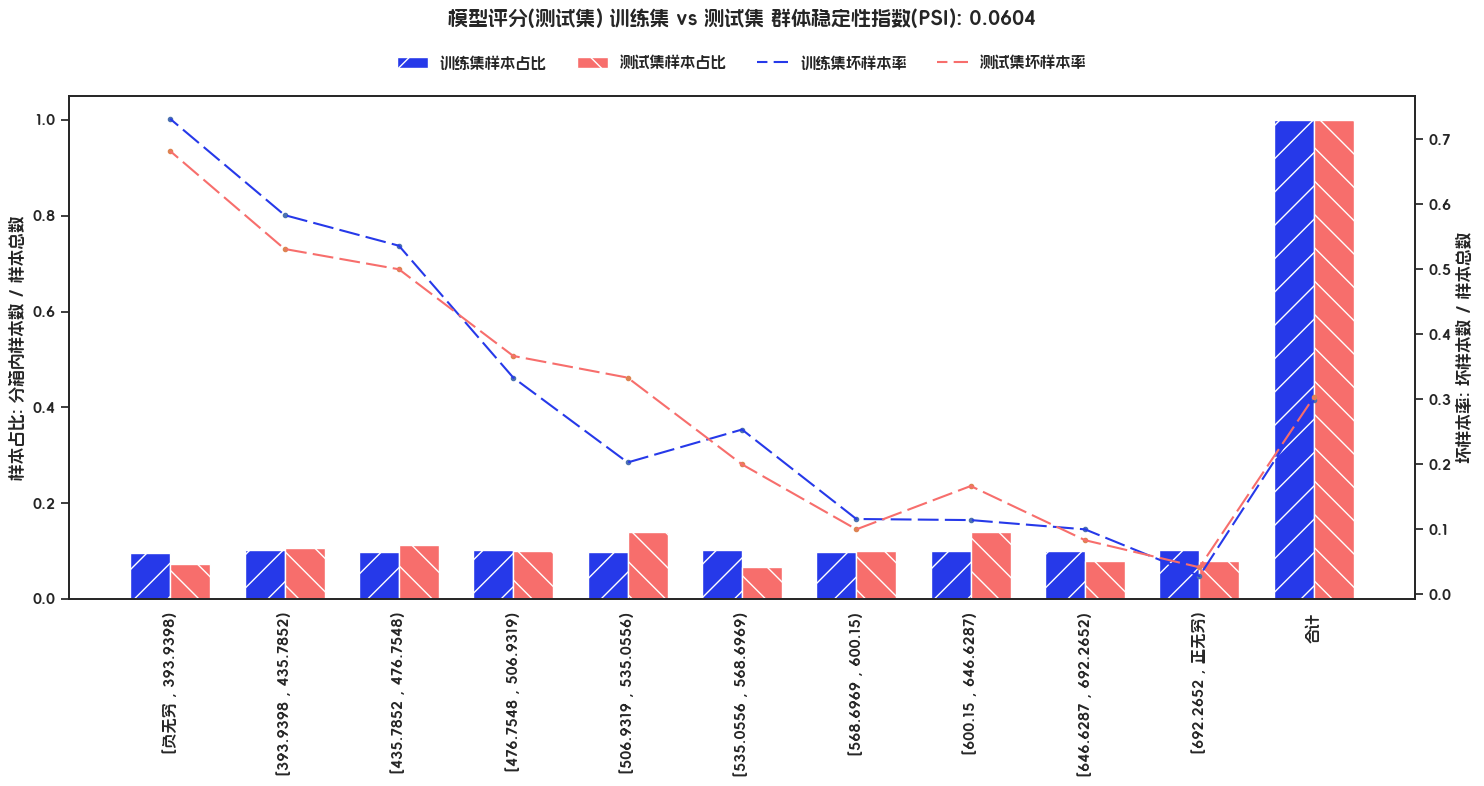

In [22]:
# 生成完整报告（包含图表）
report.to_excel(
    filepath='credit_scorecard_report.xlsx',
    n_bins=10,
    bin_method='quantile',
    with_plots=True,
    model_name='CreditScoreCard',
    project_desc='德国信贷评分卡模型（详细版）',
    feature_map=feature_map,
    data_source='German Credit Dataset',
)

In [23]:
# 查看生成的报告文件
for f in ['model_report.xlsx', 'credit_scorecard_report.xlsx']:
    if os.path.exists(f):
        print(f"{f}: {os.path.getsize(f) / 1024:.2f} KB")

# 查看图表目录
if os.path.exists('credit_scorecard_report_assets'):
    print("\n生成的图表文件:")
    for f in os.listdir('credit_scorecard_report_assets'):
        print(f"  - {f}")

model_report.xlsx: 8026.80 KB
credit_scorecard_report.xlsx: 8026.82 KB

生成的图表文件:
  - bin_installment_rate_in_percentage_of_disposable_income_test.png
  - bin_present_residence_since_train.png
  - bin_telephone_train.png
  - bin_age_in_years_train.png
  - bin_test.png
  - bin_duration_in_month_train.png
  - bin_housing_test.png
  - score_psi_test.png
  - bin_credit_history_train.png
  - bin_status_of_existing_checking_account_test.png
  - bin_present_employment_since_test.png
  - bin_creditability_train.png
  - bin_number_of_people_being_liable_to_provide_maintenance_for_train.png
  - bin_present_residence_since_test.png
  - bin_duration_in_month_test.png
  - bin_other_installment_plans_test.png
  - bin_present_employment_since_train.png
  - ks_train.png
  - bin_housing_train.png
  - bin_credit_amount_test.png
  - bin_job_test.png
  - bin_telephone_test.png
  - bin_job_train.png
  - bin_creditability_test.png
  - bin_other_installment_plans_train.png
  - bin_personal_status_and_sex_trai

### 总结

本 notebook 演示了：

1. **Pipeline 构建评分卡**：使用 `FeatureSelection`、`Combiner`、`WOETransformer`、`StepwiseSelection` 构建端到端评分卡建模流程

2. **评分卡模型训练**：使用 `ScoreCard` 构建评分卡模型，支持系数查看、刻度配置、分值表生成

3. **自动报告生成**：使用 `auto_model_report` 或 `QuickModelReport` 一键生成多 Sheet 结构的 Excel 模型评估报告

报告包含以下内容：
- 目录（带超链接）
- 1-基本信息（项目目标、样本统计）
- 2-模型性能（KS/AUC/PSI、TOP n% LIFT、评分分箱）
- 3-入模变量分析（重要性、相关性、逐特征分箱）
- 4-稳定性分析（评分分布、PSI矩阵、漂移分析）
- 5-模型参数（评分卡分值表）
- 6-模型部署需求（入模变量信息、测试用例）